In [1]:
!pip install -q scikit-learn albumentations rasterio tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 88.7 MB/s eta 0:00:00:00:0100:01


In [2]:
import os, random, csv, pickle, time
from pathlib import Path
from tqdm import tqdm                                                   

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
import albumentations as A
import cv2

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

import torch
from torch.profiler import profile, record_function, ProfilerActivity

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR   = '/kaggle/input/cloud-masking-dataset/content/train'
OUTPUT_DIR = '/kaggle/working'
MODEL_PATH = os.path.join(OUTPUT_DIR, 'cloud_mask_rf.pkl')
CSV_PATH   = os.path.join(OUTPUT_DIR, 'dice_scores_rf.csv')
LOGS_PATH  = os.path.join(OUTPUT_DIR, 'rf_profiler.txt')

CONFIG = {
    'img_size'        : 512,      # original image size (square)
    'resize_for_rf'   : 256,      # down-scale for RF inference
    'n_estimators'    : 150,
    'max_depth'       : None,
    'train_pixels'    : 250_000,  # total pixels sampled for training
    'pixels_per_class_per_img': 300,
    'rf_batch'        : 65_536,   # pixels forwarded through RF at once
    'val_split'       : 0.20,
    'device'          : torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

print(f'Using device  ➜  {CONFIG["device"]}')

Using device  ➜  cuda


In [4]:
DATASET_PATH   = Path(DATA_DIR)
IMAGES_DIR     = DATASET_PATH / 'data'
MASKS_DIR      = DATASET_PATH / 'masks'

image_paths = sorted(IMAGES_DIR.rglob("*.tif"))
mask_paths  = sorted(MASKS_DIR.rglob("*.tif"))

print(f'Total images: {len(image_paths)}  |  Total masks: {len(mask_paths)}')

Total images: 10573  |  Total masks: 10573


In [5]:
def read_image(path):
    """Return H×W×4 float32 in [0,1]."""
    with rasterio.open(path) as src:
        img = np.stack([src.read(i+1) for i in range(4)], axis=2).astype(np.float32)
    for c in range(4):
        m = img[...,c].max()
        if m>0: img[...,c] /= m
    return img

def read_mask(path):
    """Return H×W uint8 binary mask."""
    with rasterio.open(path) as src:
        m = src.read(1)
    return (m>0).astype(np.uint8)

def dice_coef(pred, gt, eps=1e-6):
    inter = np.logical_and(pred, gt).sum()
    return (2*inter+eps)/(pred.sum()+gt.sum()+eps)

In [6]:
train_img, val_img, train_msk, val_msk = train_test_split(
    image_paths, mask_paths,
    test_size=CONFIG['val_split'],
    random_state=SEED, shuffle=True)

print(f'Train imgs: {len(train_img)} | Val imgs: {len(val_img)}')

Train imgs: 8458 | Val imgs: 2115


In [7]:
def build_pixel_dataset(img_paths, msk_paths, max_pixels):
    X, y = [], []
    per_class = CONFIG['pixels_per_class_per_img']
    bar = tqdm(zip(img_paths, msk_paths), total=len(img_paths), desc='Sampling pixels')
    for im_p, ms_p in bar:
        img = read_image(im_p)
        msk = read_mask(ms_p)
        
        # indices
        cloud_idx = np.argwhere(msk==1)
        clear_idx = np.argwhere(msk==0)
        if len(cloud_idx):
            sel = cloud_idx[np.random.choice(len(cloud_idx),
                                             min(per_class, len(cloud_idx)),
                                             replace=False)]
            X.append(img[sel[:,0], sel[:,1]])
            y.extend([1]*len(sel))
        if len(clear_idx):
            sel = clear_idx[np.random.choice(len(clear_idx),
                                             min(per_class, len(clear_idx)),
                                             replace=False)]
            X.append(img[sel[:,0], sel[:,1]])
            y.extend([0]*len(sel))
        if len(y)>=max_pixels: break

    X = np.vstack(X)[:max_pixels]
    y = np.array(y)[:max_pixels]
    print(f'Pixel dataset ➜  {X.shape[0]} samples   clouds={y.sum()}  clear={len(y)-y.sum()}')
    return X, y

In [8]:
pixel_X, pixel_y = build_pixel_dataset(train_img, train_msk, CONFIG['train_pixels'])

Sampling pixels:   6%|▌         | 492/8458 [00:49<13:29,  9.84it/s]

Pixel dataset ➜  250000 samples   clouds=138089  clear=111911


In [9]:
rf_clf = RandomForestClassifier(
    n_estimators = CONFIG['n_estimators'],
    max_depth    = CONFIG['max_depth'],
    n_jobs       = -1,
    random_state = SEED,
    verbose      = 0
)

In [10]:
print('Fitting Random-Forest …')
rf_clf.fit(pixel_X, pixel_y)

with open(MODEL_PATH, 'wb') as f: pickle.dump(rf_clf, f)
print(f'Model saved ➜  {MODEL_PATH}')

Fitting Random-Forest …
Model saved ➜  /kaggle/working/cloud_mask_rf.pkl


In [11]:
def predict_mask(img, model, resize_to=256, batch=65_536):
    """img: H×W×4  float, returns binary mask H×W."""
    H,W,_ = img.shape
    if (H!=resize_to) or (W!=resize_to):
        img_r = cv2.resize(img, (resize_to,resize_to), interpolation=cv2.INTER_LINEAR)
    else:
        img_r = img
    
    flat = img_r.reshape(-1,4)
    preds = np.zeros(flat.shape[0], dtype=np.uint8)
    for i in range(0, flat.shape[0], batch):
        preds[i:i+batch] = model.predict(flat[i:i+batch])
    mask_r = preds.reshape(img_r.shape[:2])
    
    if (H!=resize_to) or (W!=resize_to):
        mask = cv2.resize(mask_r, (W,H), interpolation=cv2.INTER_NEAREST)
    else:
        mask = mask_r
    return mask

In [12]:
dice_scores = []
with open(CSV_PATH, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['img_path','mask_path','dice'])
    bar = tqdm(zip(val_img, val_msk), total=len(val_img), desc='Validating')
    for img_p, msk_p in bar:
        img  = read_image(img_p)
        gt   = read_mask(msk_p)
        pred = predict_mask(img, rf_clf,
                            resize_to=CONFIG['resize_for_rf'],
                            batch=CONFIG['rf_batch'])
        d = dice_coef(pred, gt)
        dice_scores.append(d)
        writer.writerow([img_p, msk_p, d])        
        bar.set_postfix(mean_dice=f"{np.mean(dice_scores):.4f}")
        
print(f'Mean Dice on validation  ➜  {np.mean(dice_scores):.4f}')
print(f'Dice scores CSV saved    ➜  {CSV_PATH}')

Validating: 100%|██████████| 2115/2115 [25:23<00:00,  1.39it/s, mean_dice=0.7437]

Mean Dice on validation  ➜  0.7437
Dice scores CSV saved    ➜  /kaggle/working/dice_scores_rf.csv


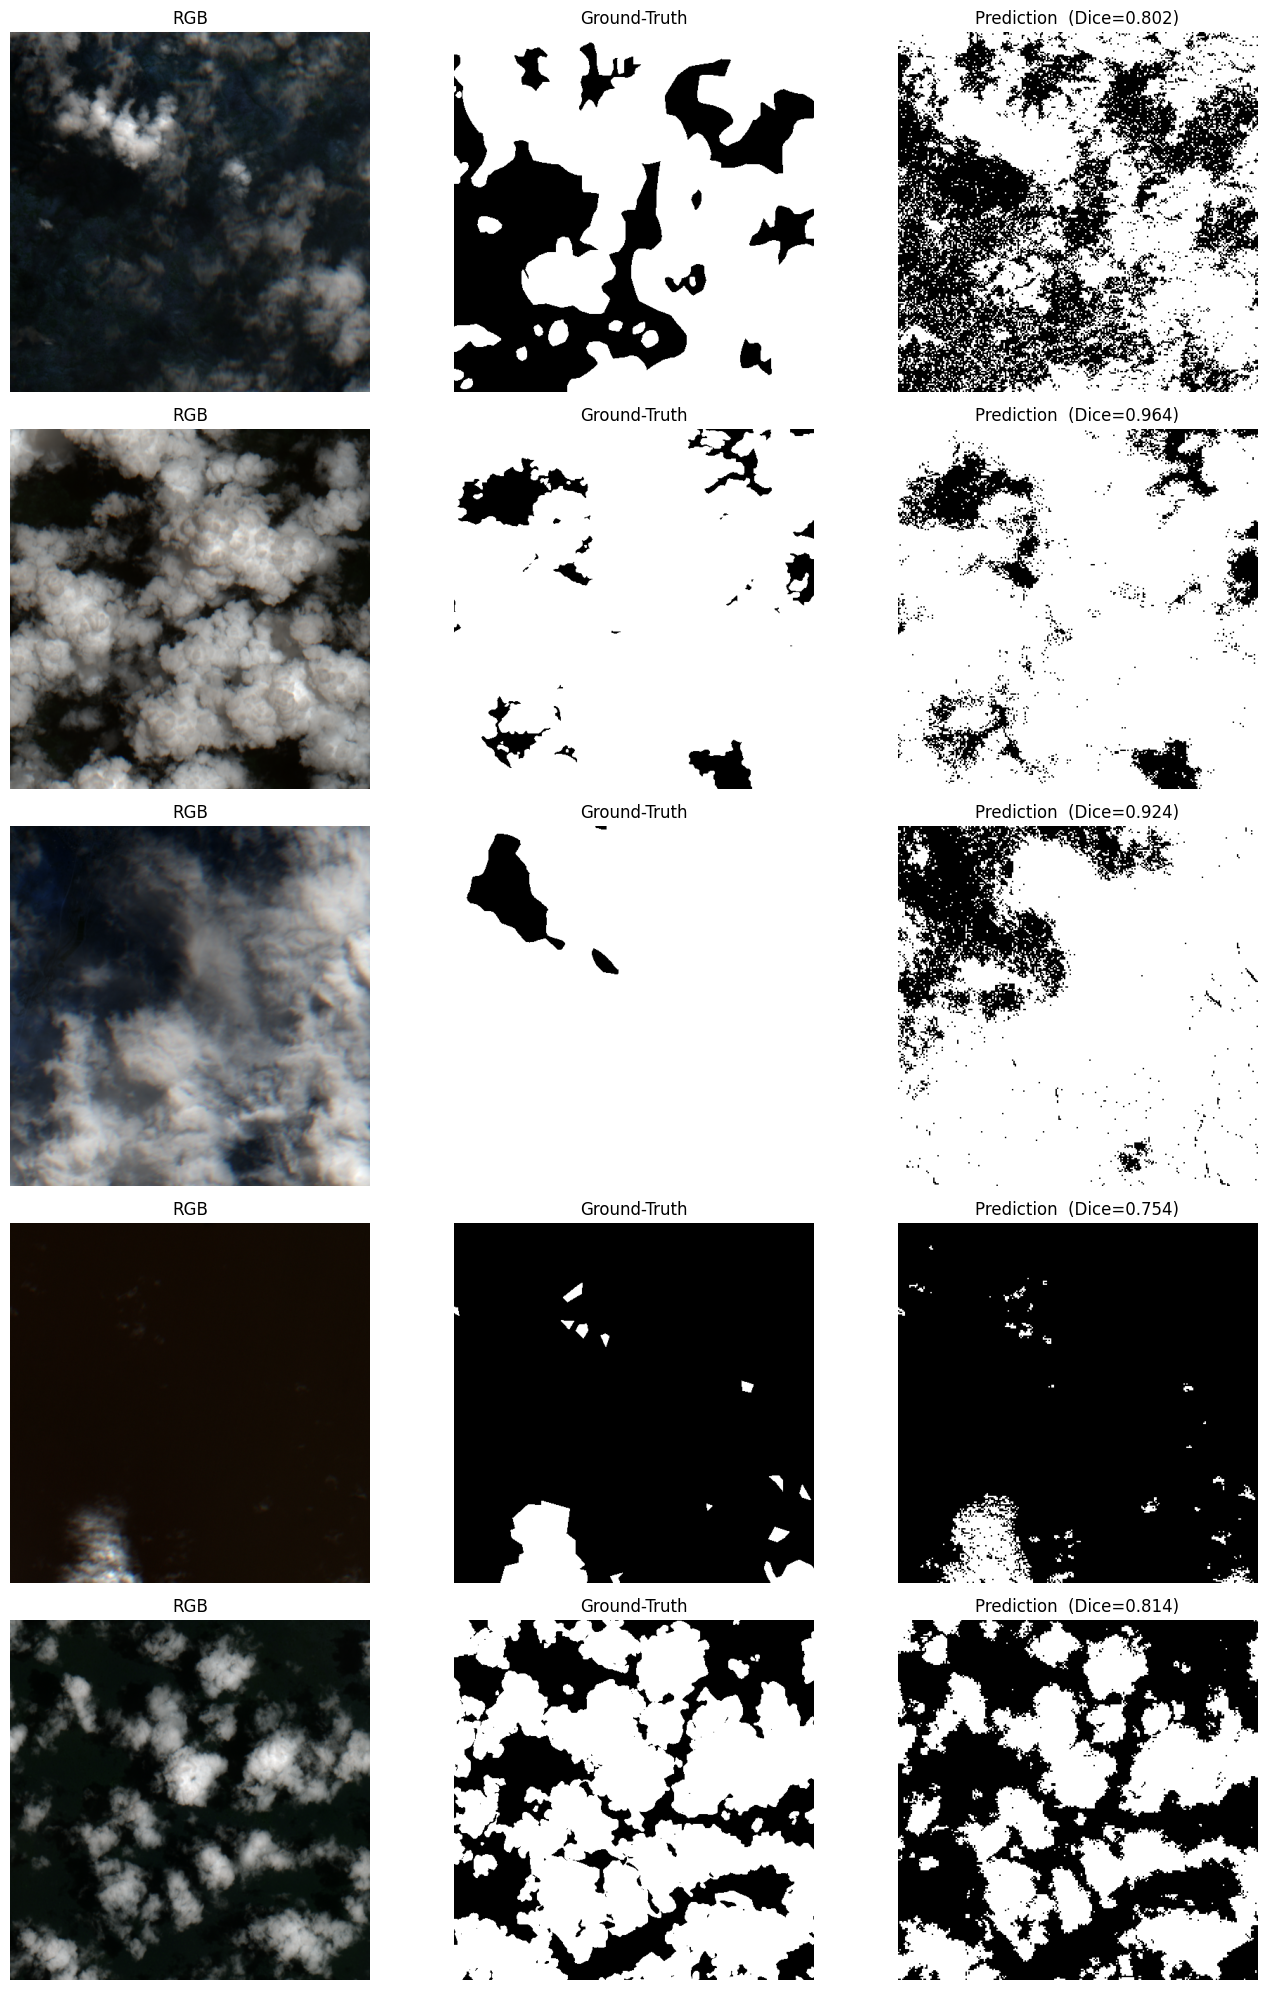

In [13]:
SAMPLES = 5
idxs = np.random.choice(len(val_img), SAMPLES, replace=False)
fig, axes = plt.subplots(SAMPLES,3, figsize=(14,4*SAMPLES))
for row,idx in enumerate(idxs):
    img = read_image(val_img[idx])
    gt  = read_mask(val_msk[idx])
    prd = predict_mask(img, rf_clf, resize_to=CONFIG['resize_for_rf'])
    
    rgb = (img[...,:3]-img[...,:3].min())/(img[...,:3].ptp()+1e-6)
    axes[row,0].imshow(rgb); axes[row,0].set_axis_off(); axes[row,0].set_title('RGB')
    axes[row,1].imshow(gt, cmap='gray'); axes[row,1].set_axis_off(); axes[row,1].set_title('Ground-Truth')
    axes[row,2].imshow(prd, cmap='gray'); axes[row,2].set_axis_off(); 
    axes[row,2].set_title(f'Prediction  (Dice={dice_coef(prd,gt):.3f})')
plt.tight_layout(); plt.show()

In [14]:
sample_img = read_image(val_img[0])
flat_tensor = torch.from_numpy(sample_img.reshape(-1,4))

with profile(activities=[ProfilerActivity.CPU],
             profile_memory=True, record_shapes=True) as prof:
    with record_function("rf_inference"):
        _ = rf_clf.predict(flat_tensor.numpy())

with open(LOGS_PATH,'w') as f: f.write(str(prof.key_averages().table(sort_by="cpu_time_total")))
print(f'Profiler report saved ➜  {LOGS_PATH}')

Profiler report saved ➜  /kaggle/working/rf_profiler.txt


Dice ⇒  min:0.000 | median:0.865 | mean:0.744 | max:1.000


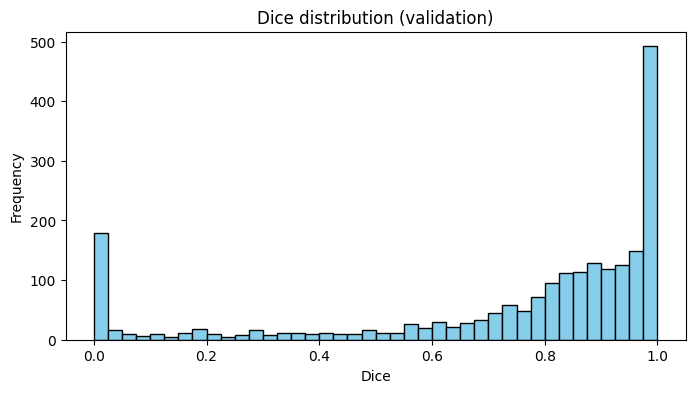

In [15]:
d_arr = np.array(dice_scores)
print(f'Dice ⇒  min:{d_arr.min():.3f} | median:{np.median(d_arr):.3f} | mean:{d_arr.mean():.3f} | max:{d_arr.max():.3f}')

plt.figure(figsize=(8,4))
plt.hist(d_arr, bins=40, color='skyblue', edgecolor='black')
plt.xlabel('Dice'); plt.ylabel('Frequency'); plt.title('Dice distribution (validation)')
plt.show()